In [2]:
import torch

from utils.checkpoints import load_ae_from_path, load_cspn_from_path
from visualisation import show, plot_latent_comparison, plot_latent_comparison_multiclass
from checkpoints import load_from_wandb
from utils.config import DatasetConfig
from dataset_loaders import build_data_loaders
from pathlib import Path


In [3]:
ae_path = Path("../checkpoints/autoencoder/mnist.pt")
ae = load_ae_from_path(ae_path)


In [4]:
dataset_cfg = DatasetConfig(
    name="mnist",
    channels=3,
    height=28,
    width=28,
    num_classes=10,
    num_workers=1
)

dataloader, _ = build_data_loaders(dataset_cfg, batch_size=64)


In [5]:
cspn_spf_path = Path("../checkpoints/cspn/mnist_spflow.pt")
cspn_spf = load_cspn_from_path(cspn_spf_path)

FileNotFoundError: [Errno 2] No such file or directory: '../checkpoints/cspn/mnist_spflow.pt'

In [6]:
cspn_custom_path = Path("../checkpoints/cspn/mnist_custom.pt")
cspn_custom = load_cspn_from_path(cspn_custom_path)

In [7]:
cspn_psi_path = load_from_wandb("CSPN_mnist_psinet", "", "mnist_psi.pt")
cspn_psi = load_cspn_from_path(cspn_psi_path, device=torch.device("cpu"))


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jakob/.netrc.
wandb: Downloading large artifact 'CSPN_mnist_psinet:latest', 57.58MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.3 (168.6MB/s)


{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


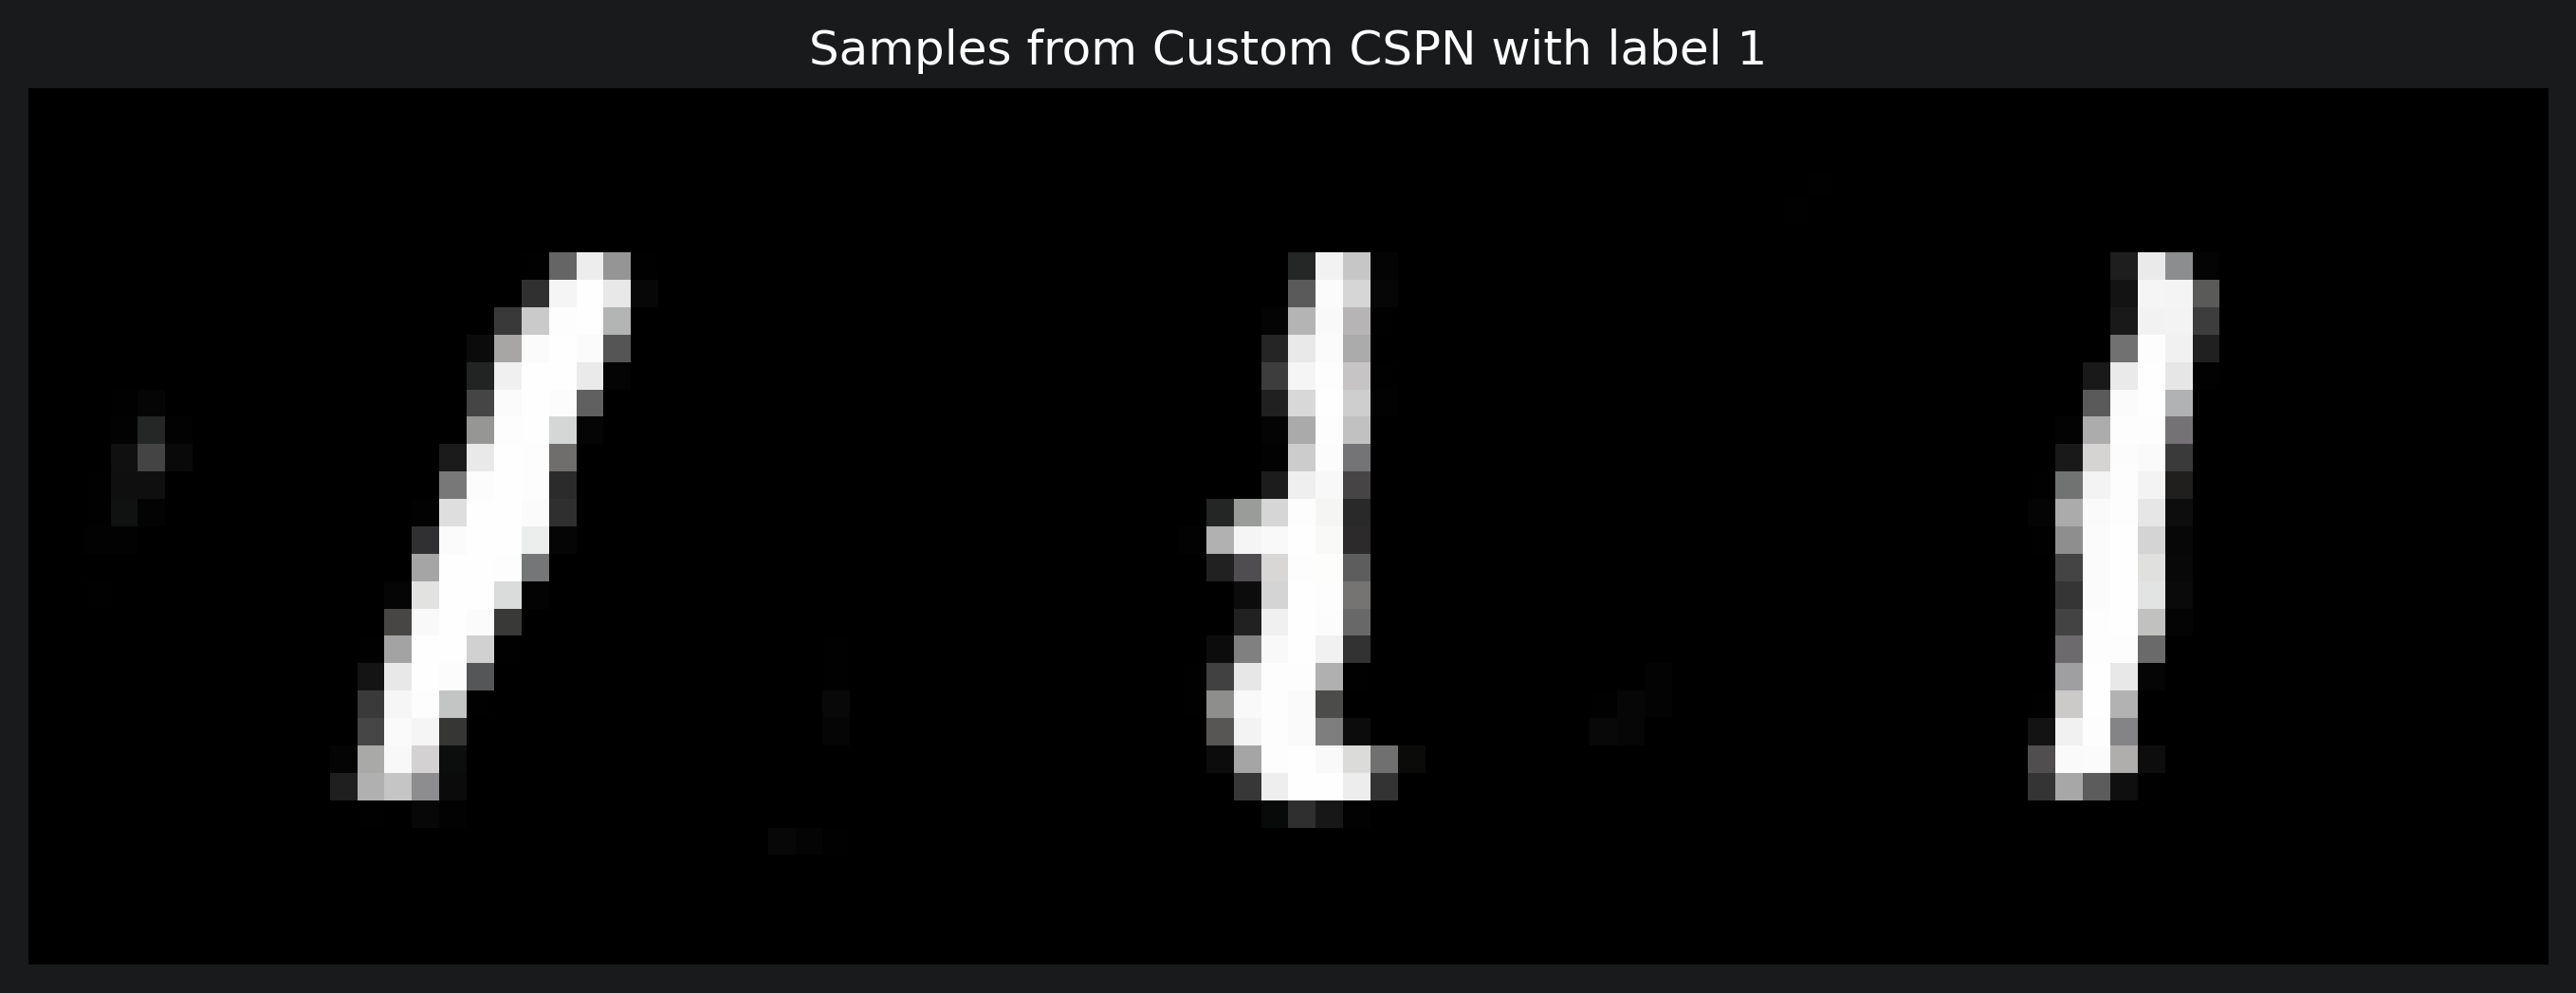

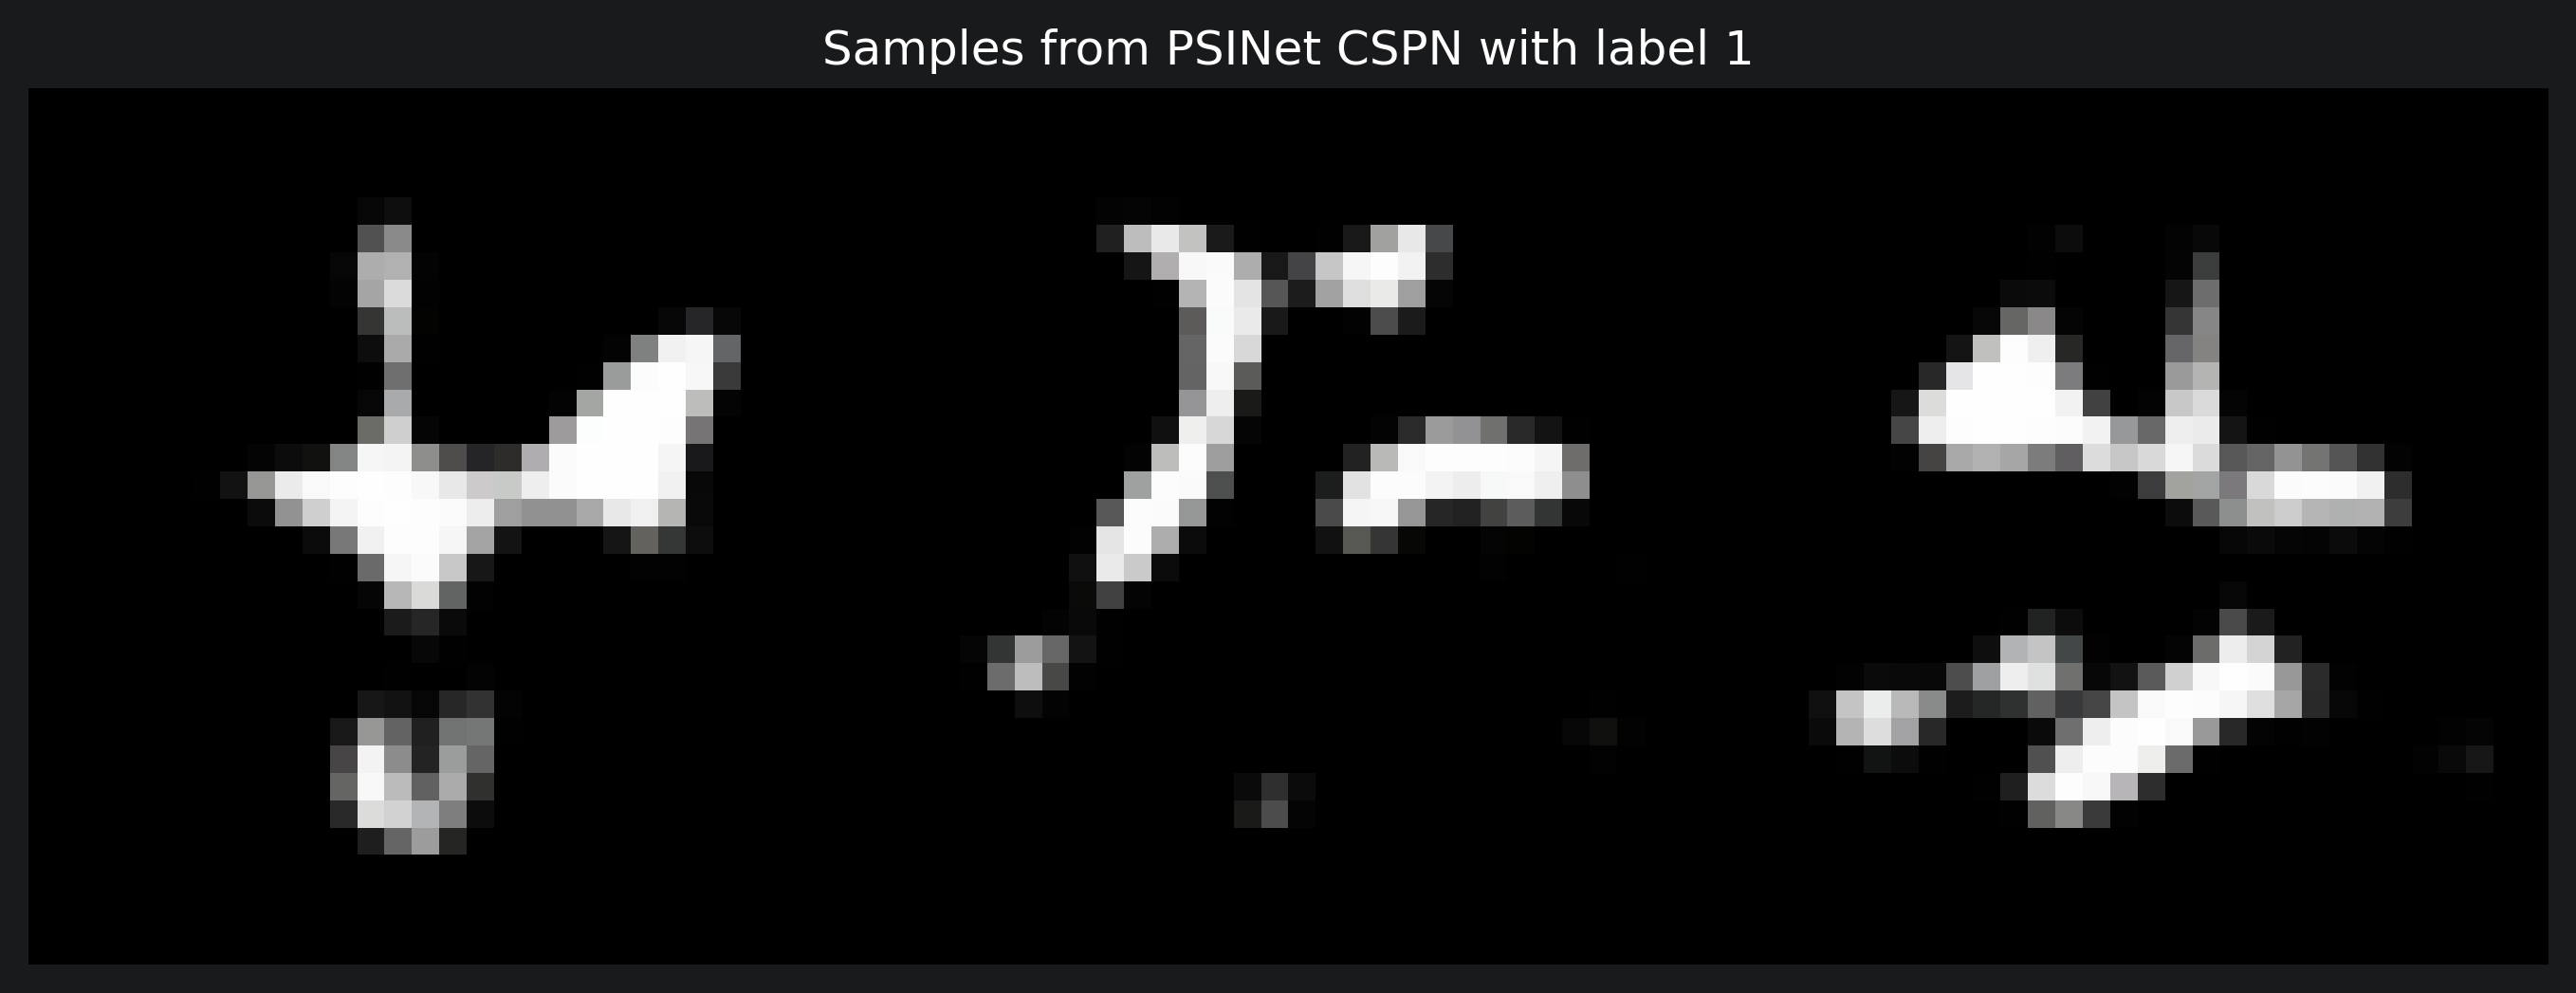

In [8]:
label = 1
sample_labels = torch.tensor([label] * 3)

with torch.no_grad():
    #samples_spf = cspn_spf.sample(sample_labels)
    #sampled_images_spf = ae.decode(samples_spf)
    samples_custom = cspn_custom.sample(sample_labels)
    sampled_images_custom = ae.decode(samples_custom)
    samples_psi = cspn_psi.sample(sample_labels)
    sampled_images_psi = ae.decode(samples_psi)

#show(sampled_images_spf, f"Samples from SPFlowCSPN with label {label}")
show(sampled_images_custom, f"Samples from Custom CSPN with label {label}")
show(sampled_images_psi, f"Samples from PSINet CSPN with label {label}")

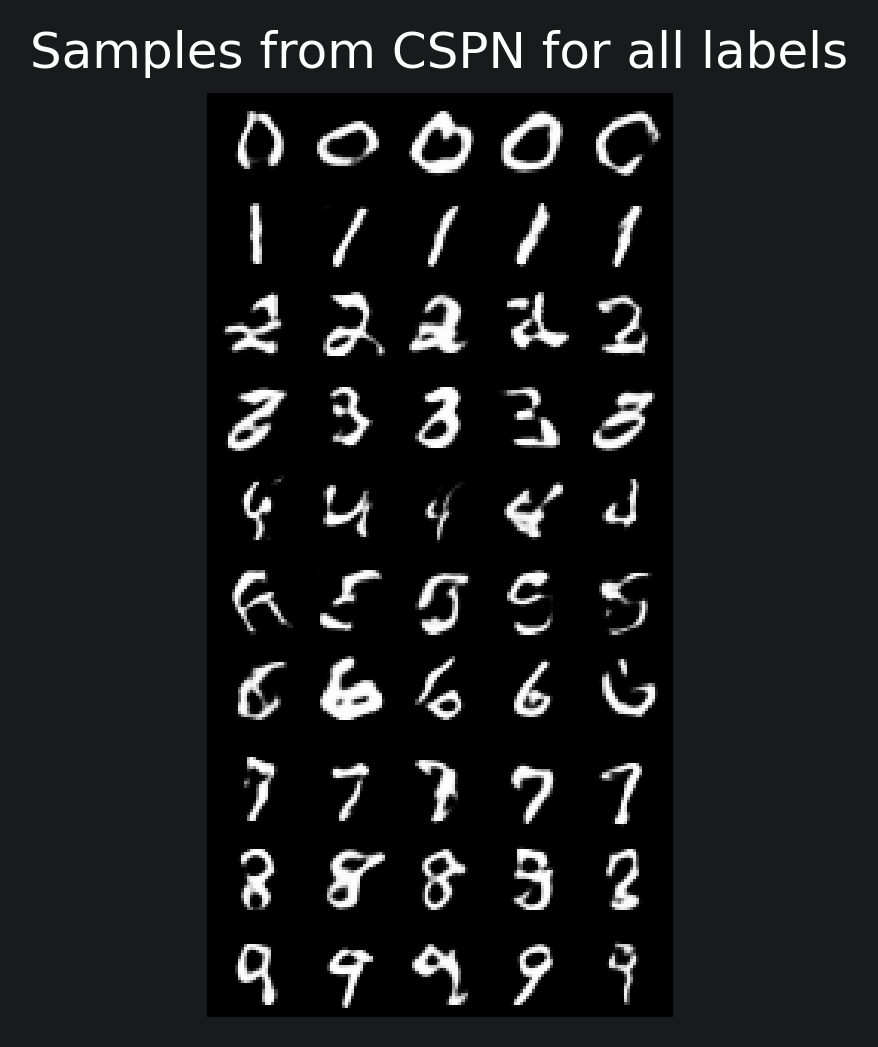

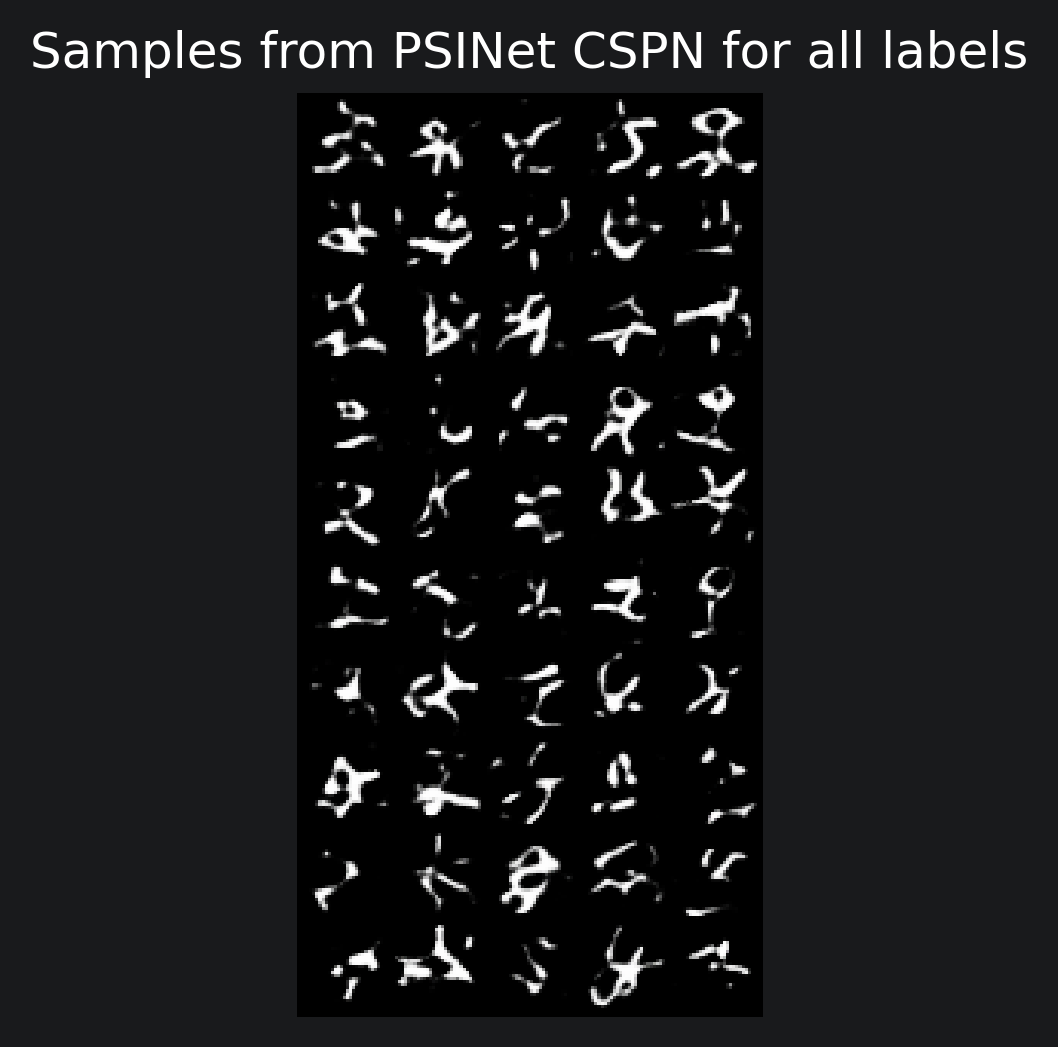

In [9]:
all_labels = torch.arange(10).repeat_interleave(5)

with torch.no_grad():
    samples = cspn_custom.sample(all_labels)
    sampled_images = ae.decode(samples)
    samples_psi = cspn_psi.sample(all_labels)
    sampled_images_psi = ae.decode(samples_psi)

show(sampled_images, "Samples from CSPN for all labels", width=5)
show(sampled_images_psi, "Samples from PSINet CSPN for all labels", width=5)

In [10]:
comparison_label = 4
comparison_labels = torch.tensor([comparison_label] * 20)

with torch.no_grad():
    samples_spf = cspn_spf.sample(comparison_labels)
    sampled_images_spf = ae.decode(samples_spf)
    samples_custom = cspn_custom.sample(comparison_labels)
    sampled_images_custom = ae.decode(samples_custom)

plot_latent_comparison(latents_a=samples_spf, latents_b=samples_custom, name_a="SPFlowCSPN", name_b="Custom CSPN",
                       title=f"SPFlowCSPN with label {comparison_label}")


NameError: name 'cspn_spf' is not defined

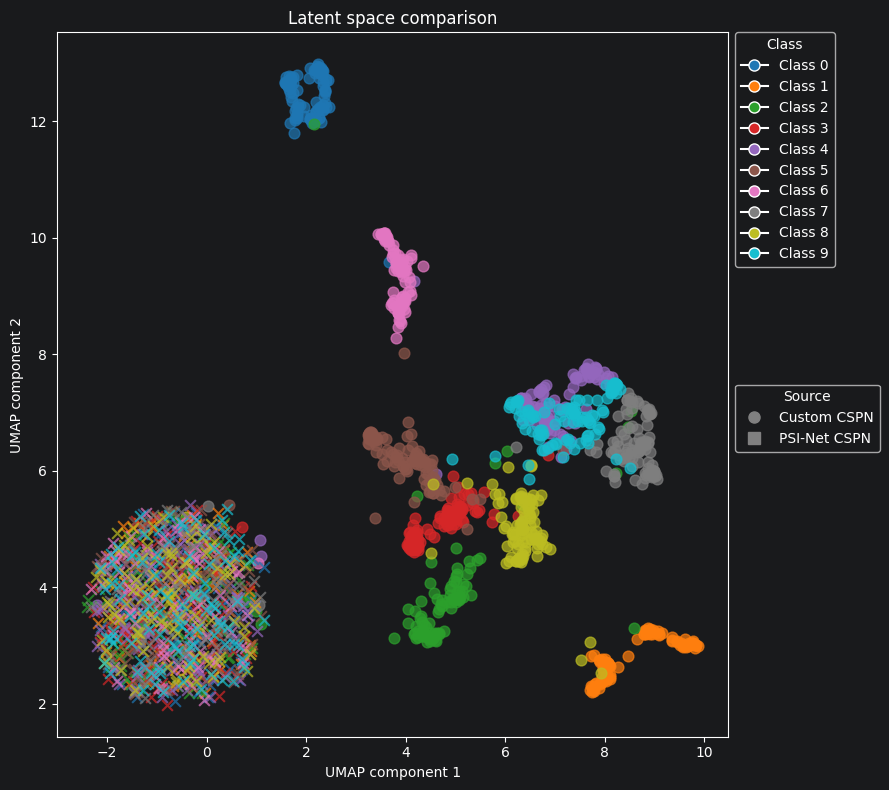

In [14]:
sample_multi_labels = torch.arange(10).repeat_interleave(100)
with torch.no_grad():
    samples_custom = cspn_custom.sample(sample_multi_labels)
    samples_psi = cspn_psi.sample(sample_multi_labels)

plot_latent_comparison_multiclass(samples_custom, samples_psi, sample_multi_labels,
                                  name_a="Custom CSPN", name_b="PSI-Net CSPN")
